# Hex-level evaluation

Loads and visualizes the TAZ/hex/ceiling metrics for a trained run. The actual
computation happens in `scripts/evaluate.py` - run that first, in a tmux
session (it's heavy enough that running it inside a notebook kernel kept
crashing):

```bash
python scripts/evaluate.py                    # evaluates the most recently trained run
python scripts/evaluate.py <path/to/run_dir>  # evaluates a specific run
```

This notebook just reads the `eval_results.pkl` it saves and plots it.

In [15]:
import glob
import os
import pickle

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from qol_surrogate.data import TRANSPORT_MODES

In [16]:
MODELS_DIR = "../models"

# picks the most recently trained run - point this at a specific folder instead to load an older run
run_dirs = sorted(d for d in glob.glob(os.path.join(MODELS_DIR, "gcn_resnet_*")) if os.path.isdir(d))
run_dir = run_dirs[-1]
run_dir

'../models/gcn_resnet_20260811_154832'

In [ ]:
results_path = os.path.join(run_dir, "eval_results.pkl")

if not os.path.exists(results_path):
    raise FileNotFoundError(
        f"{results_path} doesn't exist yet - run `python scripts/evaluate.py` "
        f"(e.g. in a tmux session) first, then re-run this cell."
    )

with open(results_path, "rb") as f:
    results = pickle.load(f)

if "hex_per_taz" not in results:
    raise KeyError(
        f"{results_path} is from before the per-TAZ hex-resolution metric existed - "
        f"re-run `python scripts/evaluate.py` to regenerate it."
    )

print(f"Loaded evaluation from {results_path}")
results["taz"]["deviation"]["overall"], results["taz"]["absolute"]["overall"]

## TAZ deviation, per channel

What the model is actually trained to predict: the flood-induced *change* in accessibility, per (mode, POI category).

In [18]:
deviation_table = pd.DataFrame({
    metric: {col: m[metric] for col, m in results["taz"]["deviation"]["per_channel"].items()}
    for metric in ("r2", "mae", "c_index", "wape")
})
deviation_table

,r2,mae,c_index,wape
cumulative_accessibility_CAR_cultural,0.990706,8.906299,0.963560,0.010333
cumulative_accessibility_CAR_education,0.986596,5.825286,0.953770,0.010746
cumulative_accessibility_CAR_green_space,0.652992,9.710464,0.794725,0.331326
cumulative_accessibility_CAR_health,0.904434,10.923781,0.913053,0.046920
cumulative_accessibility_CAR_public_spaces,0.708897,7.312612,0.841276,0.133781
cumulative_accessibility_CAR_public_transportation,0.930566,27.475517,0.924981,0.040560
cumulative_accessibility_CAR_sports,0.832665,16.178856,0.884471,0.073571
cumulative_accessibility_BICYCLE_cultural,0.992262,3.871224,0.971969,0.020413
cumulative_accessibility_BICYCLE_education,0.993345,2.706365,0.975232,0.020809
cumulative_accessibility_BICYCLE_green_space,0.939233,3.524141,0.931098,0.100854


## TAZ vs. hex, per channel (absolute accessibility)

`evaluate_hex_level` is always in absolute units - there's no hex-resolution dry
baseline to build a hex-level deviation from (the old repo's attempt at this
crashed and was never finished either). So the fair comparison here is
TAZ-absolute vs. hex-absolute: if hex-level numbers are close to TAZ-level
numbers, the model's remaining error is mostly resolution loss, not something
more training/tuning would fix - same conclusion the old repo's
perfect-surrogate-ceiling check was chasing.

In [19]:
comparison = pd.DataFrame({
    "taz_r2":      {col: m["r2"]      for col, m in results["taz"]["absolute"]["per_channel"].items()},
    "hex_r2":      {col: m["r2"]      for col, m in results["hex"].items()},
    "taz_mae":     {col: m["mae"]     for col, m in results["taz"]["absolute"]["per_channel"].items()},
    "hex_mae":     {col: m["mae"]     for col, m in results["hex"].items()},
    "taz_c_index": {col: m["c_index"] for col, m in results["taz"]["absolute"]["per_channel"].items()},
    "hex_c_index": {col: m["c_index"] for col, m in results["hex"].items()},
    "taz_wape":    {col: m["wape"]    for col, m in results["taz"]["absolute"]["per_channel"].items()},
    "hex_wape":    {col: m["wape"]    for col, m in results["hex"].items()},
})
comparison

,taz_r2,hex_r2,taz_mae,hex_mae,taz_c_index,hex_c_index,taz_wape,hex_wape
cumulative_accessibility_CAR_cultural,0.952115,0.651061,8.906299,23.944387,0.854590,0.832137,0.034882,0.098597
cumulative_accessibility_CAR_education,0.953272,0.657743,5.825286,15.819423,0.883206,0.852415,0.033044,0.094960
cumulative_accessibility_CAR_green_space,0.921446,0.480748,9.710464,34.248867,0.923144,0.867945,0.024033,0.089987
cumulative_accessibility_CAR_health,0.938510,0.546751,10.923781,35.629681,0.926312,0.875668,0.026275,0.091748
cumulative_accessibility_CAR_public_spaces,0.876545,0.374951,7.312612,26.851391,0.896008,0.840575,0.023043,0.088452
cumulative_accessibility_CAR_public_transportation,0.944185,0.570027,27.475517,87.366310,0.931029,0.877447,0.027145,0.092719
cumulative_accessibility_CAR_sports,0.936796,0.555337,16.178856,55.857185,0.930867,0.882009,0.024106,0.089131
cumulative_accessibility_BICYCLE_cultural,0.981813,0.849672,3.871224,8.212979,0.949962,0.868917,0.078263,0.223212
cumulative_accessibility_BICYCLE_education,0.978295,0.836187,2.706365,5.820505,0.951145,0.874215,0.077665,0.219415
cumulative_accessibility_BICYCLE_green_space,0.981598,0.783802,3.524141,11.119315,0.961216,0.875257,0.049317,0.192330


## Per-mode summary: TAZ vs. hex vs. ceiling

Two bars per transport mode - the model's own TAZ-resolution performance and the same model broadcast to hex-resolution - plus a short horizontal line, drawn only over the hex bar (in a lighter shade of the same blue), marking the ceiling for that mode/metric. The ceiling only applies to the hex bar since they're scored against the same target (true hex data) - the TAZ bar is scored against a different, smoother target, so it isn't bounded by this ceiling at all (see the earlier discussion on why TAZ can legitimately score *above* it).

"Ceiling" is the *real* perfect-surrogate ceiling: the true TAZ-level absolute accessibility (not a model prediction) broadcast to every hex within that TAZ, scored against the true hex data - no model involved at all, so any remaining gap from a perfect score is *pure* resolution loss, not something more training could ever close. Same concept as the old repo's `evaluate_perfect_surrogate.py`.

For R² and C-index, a thin dashed gray line at 1.0 marks the absolute best any score could ever be, for reference alongside the resolution ceiling. WAPE has no such line - 0 is its ideal, not 1.

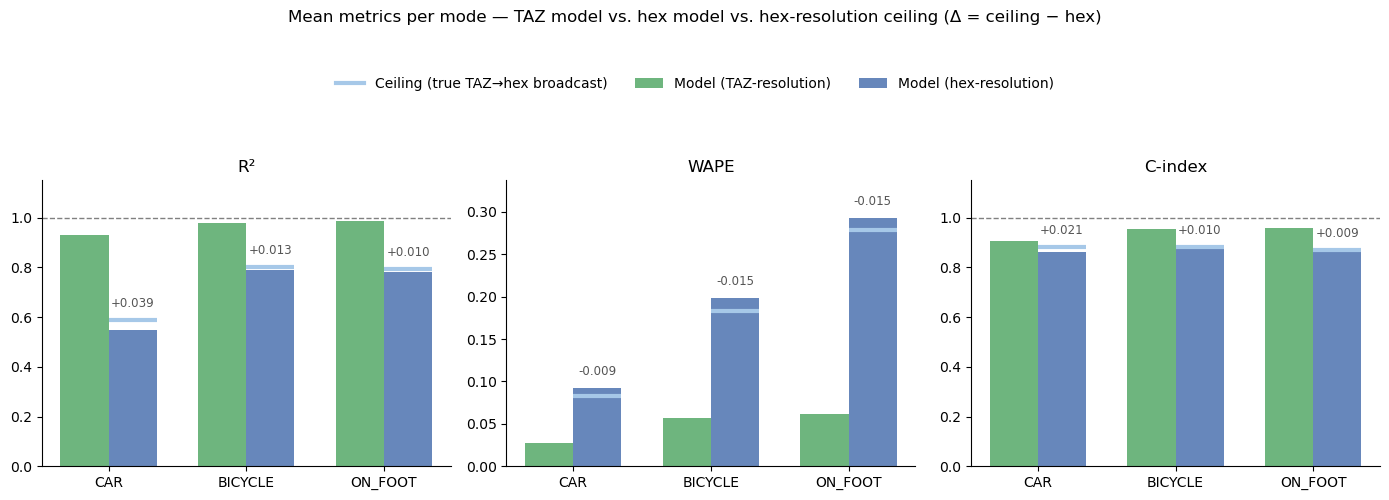

In [20]:
METRICS_SUMMARY = ['r2', 'wape', 'c_index']
METRIC_LABELS = {'r2': 'R²', 'wape': 'WAPE', 'c_index': 'C-index'}
METRICS_WITH_MAX_1 = {'r2', 'c_index'}  # WAPE's ideal is 0, not 1 - no max-possible line for it

COLOR_TAZ = '#55A868'
COLOR_HEX = '#4C72B0'      # darker blue = the actual hex-resolution model
COLOR_CEILING = '#A6C8E8'  # lighter shade of the SAME blue - visually tied to the hex bar it belongs to
BAR_WIDTH = 0.35
x = np.arange(len(TRANSPORT_MODES))


def per_mode_mean(per_channel_dict, mode, metric):
    vals = [m[metric] for col, m in per_channel_dict.items()
            if col.startswith(f"cumulative_accessibility_{mode}_")]
    return np.nanmean(vals)


fig, axes = plt.subplots(1, len(METRICS_SUMMARY), figsize=(14, 4.5))

for ax, metric in zip(axes, METRICS_SUMMARY):
    taz_means     = np.array([per_mode_mean(results["taz"]["absolute"]["per_channel"], mode, metric)
                               for mode in TRANSPORT_MODES])
    hex_means     = np.array([per_mode_mean(results["hex"], mode, metric) for mode in TRANSPORT_MODES])
    ceiling_means = np.array([per_mode_mean(results["ceiling"], mode, metric) for mode in TRANSPORT_MODES])

    x_taz = x - BAR_WIDTH / 2
    x_hex = x + BAR_WIDTH / 2

    ax.bar(x_taz, taz_means, width=BAR_WIDTH, color=COLOR_TAZ, alpha=0.85, zorder=2,
           label='Model (TAZ-resolution)')
    ax.bar(x_hex, hex_means, width=BAR_WIDTH, color=COLOR_HEX, alpha=0.85, zorder=2,
           label='Model (hex-resolution)')

    # ceiling only applies to the hex bar (same target resolution) - draw it only over that bar's width
    for xi, cv in zip(x_hex, ceiling_means):
        ax.plot([xi - BAR_WIDTH / 2, xi + BAR_WIDTH / 2], [cv, cv],
                color=COLOR_CEILING, linewidth=3, solid_capstyle='butt', zorder=3)
    ax.plot([], [], color=COLOR_CEILING, linewidth=3, label='Ceiling (true TAZ→hex broadcast)')

    top = np.maximum.reduce([taz_means, hex_means, ceiling_means])
    if metric in METRICS_WITH_MAX_1:
        top = np.append(top, 1.0)
    ymax = top.max() * 1.15
    ax.set_ylim(0, ymax)
    label_pad = 0.035 * ymax
    for xi, hv, cv in zip(x_hex, hex_means, ceiling_means):
        gap = cv - hv
        ax.text(xi, max(hv, cv) + label_pad, f'{gap:+.3f}', ha='center', va='bottom',
                fontsize=8.5, color='#555555')

    if metric in METRICS_WITH_MAX_1:
        ax.axhline(1.0, color='gray', linewidth=1, linestyle='--', zorder=1)

    ax.set_xticks(x); ax.set_xticklabels(TRANSPORT_MODES)
    ax.set_title(METRIC_LABELS[metric])
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

fig.tight_layout(rect=[0, 0, 1, 0.80])
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), ncol=3, frameon=False)
fig.suptitle('Mean metrics per mode — TAZ model vs. hex model vs. hex-resolution ceiling (Δ = ceiling − hex)', y=1.1)
plt.show()

## Which TAZ zones have the highest error, per mode?

Everything above pools across all 277 TAZ zones into one number per mode/channel. This rebuilds the model and computes per-TAZ R², WAPE, and C-index (absolute accessibility, pooled across the 7 POI categories and every test scenario), then maps each - showing *where* geographically the model struggles most, for each transport mode, under three different notions of "error."

This is a lightweight, TAZ-only computation (no hex-resolution data involved), so - unlike the hex/ceiling metrics - it's fast enough to do directly in this notebook rather than in `scripts/evaluate.py`.

In [21]:
import torch
from torch_geometric.loader import DataLoader

from qol_surrogate.data import (
    ZONES_FILE, TAZ_PARQUET_DIR, TAZ_PARQUET_DIR_NO_19, DRY_BASELINE_DIR, DRY_BASELINE_DIR_NO_19,
    load_hexes, get_taz_ids, build_taz_to_idx, build_taz_geometries,
    create_edge_index, create_polygon_metrics, load_dataset_tensors, build_data_list,
)
from qol_surrogate.evaluate import evaluate_per_taz
from qol_surrogate.model import GCNResNet

checkpoint = torch.load(os.path.join(run_dir, "model.pt"), weights_only=False)
hp = checkpoint["hyperparameters"]
idx_test = checkpoint["idx_test"]
include_file_19 = checkpoint.get("include_file_19", True)
print(f"include_file_19={include_file_19}")

# placeholder buffers - load_state_dict overwrites them with the real saved values below
model = GCNResNet(
    in_channels=hp["in_channels"], hidden_channels=hp["hidden_channels"],
    out_channels=hp["out_channels"], n_layers=hp["n_layers"], dropout_rate=hp["dropout_rate"],
    x_mean=torch.zeros(hp["in_channels"]), x_std=torch.ones(hp["in_channels"]),
    y_mean=torch.zeros(hp["out_channels"]), y_std=torch.ones(hp["out_channels"]),
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

hexes = load_hexes(ZONES_FILE)
taz_ids = get_taz_ids(hexes)
taz_to_idx = build_taz_to_idx(taz_ids)
tazes = build_taz_geometries(hexes)

edge_index, edge_weight = create_edge_index(tazes, taz_to_idx)
area, perimeter = create_polygon_metrics(tazes, taz_ids)

taz_parquet_dir = TAZ_PARQUET_DIR if include_file_19 else TAZ_PARQUET_DIR_NO_19
dry_baseline_dir = DRY_BASELINE_DIR if include_file_19 else DRY_BASELINE_DIR_NO_19
x, y = load_dataset_tensors(area, perimeter, taz_parquet_dir=taz_parquet_dir, dry_baseline_dir=dry_baseline_dir)

x_test = (x[idx_test] - model.x_mean) / model.x_std
y_test = (y[idx_test] - model.y_mean) / model.y_std

test_data = build_data_list(x_test, y_test, edge_index, edge_weight)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

include_file_19=False


In [23]:
per_taz_metrics

,CAR,BICYCLE,ON_FOOT
taz_id,,,
102111,5.279934,9.644967,0.585479
102121,6.636723,4.237793,0.493549
102122,58.415203,4.343654,0.619932
102131,3.891376,4.002203,0.930558
102141,7.918505,3.742716,0.496453
...,...,...,...
185144,7.482403,1.921649,0.296143
185145,11.042418,1.656457,0.308580
185172,11.378490,2.897836,0.258705


In [22]:
per_taz_metrics = evaluate_per_taz(model, test_loader, taz_ids, dry_baseline_dir=dry_baseline_dir)
# {metric: DataFrame(taz_id x mode)} - tazes is indexed by taz_zoneid (from dissolve),
# each per-metric DataFrame is indexed by the same taz_id values, so a plain join lines them up
per_taz_metrics["r2"].describe()

KeyError: 'r2'

In [ ]:
METRIC_LABELS = {'r2': 'R²', 'wape': 'WAPE', 'c_index': 'C-index'}
# higher-is-better metrics: green=high=good, red=low=bad. WAPE is lower-is-better,
# so its colormap is reversed - green=low=good, red=high=bad
METRIC_CMAPS = {'r2': 'RdYlGn', 'c_index': 'RdYlGn', 'wape': 'RdYlGn_r'}


def plot_per_taz_map(metrics_dict, metric, title_suffix):
    df = tazes.join(metrics_dict[metric])

    fig, axes = plt.subplots(1, len(TRANSPORT_MODES), figsize=(17, 5.5))
    for ax, mode in zip(axes, TRANSPORT_MODES):
        df.plot(column=mode, cmap=METRIC_CMAPS[metric], legend=True, ax=ax,
                legend_kwds={'label': METRIC_LABELS[metric], 'shrink': 0.65})
        ax.set_title(mode)
        ax.set_axis_off()

    fig.suptitle(f'Per-TAZ {METRIC_LABELS[metric]} ({title_suffix}), by mode', y=1.03)
    plt.tight_layout()
    plt.show()


plot_per_taz_map(per_taz_metrics, "r2", "TAZ-resolution, absolute accessibility")

In [ ]:
plot_per_taz_map(per_taz_metrics, "wape", "TAZ-resolution, absolute accessibility")

In [ ]:
plot_per_taz_map(per_taz_metrics, "c_index", "TAZ-resolution, absolute accessibility")

## Hex-resolution accuracy, mapped per TAZ

The maps above compare the model's *TAZ-resolution* prediction directly against TAZ-level truth. This section instead broadcasts each TAZ's predicted absolute accessibility down to its own hexes and compares against true hex-level data - the same broadcast-and-compare mechanism as the pooled `hex`/`ceiling` metrics above - but keeps each TAZ's hexes separate instead of pooling the whole city into one number, then maps the result at TAZ granularity.

This mixes two error sources together: the model's own prediction error, and the resolution loss from representing a whole TAZ with a single value. It answers "where does hex-resolution accuracy break down," not "where does the model itself struggle" (that's what the TAZ-resolution maps above isolate).

Computed once in `scripts/evaluate.py` (`evaluate_hex_level_per_taz`) since it needs the full hex-resolution ground truth - loaded here from `results["hex_per_taz"]`, not recomputed.

In [ ]:
plot_per_taz_map(results["hex_per_taz"], "r2", "hex-resolution, absolute accessibility")

In [ ]:
plot_per_taz_map(results["hex_per_taz"], "wape", "hex-resolution, absolute accessibility")

In [ ]:
plot_per_taz_map(results["hex_per_taz"], "c_index", "hex-resolution, absolute accessibility")

## Inference latency: raw input to hex-resolution prediction

How long does one scenario take end-to-end? The TAZ-adjacency graph and the dry baseline are fixed and would be precomputed once in a real deployment (e.g. inside the RL loop), so this times only what has to happen fresh for each new scenario: normalizing the raw water-depth input, the GCN forward pass, denormalizing back to real units, adding the TAZ-level dry baseline to get absolute accessibility, and broadcasting the TAZ-resolution prediction down to every hex.

Measured as single-scenario (batch size 1) latency, since that's how the RL loop would call it - not batched throughput.

In [16]:
import time

from qol_surrogate.evaluate import _load_taz_dry_baseline

taz_idx_per_hex = hexes['taz_zoneid'].map(taz_to_idx).to_numpy()  # [n_hex] - fixed, precomputed once
y_dry_taz = _load_taz_dry_baseline(dry_baseline_dir)[0]           # [277, 21] - fixed reference, precomputed once

device = next(model.parameters()).device
x_raw_sample = x[idx_test[0]]  # one scenario's raw (un-normalized) water-depth/geometry features, [277, 5]

n_warmup, n_repeats = 10, 200
model.eval()

def run_pipeline():
    x_norm = (x_raw_sample - model.x_mean) / model.x_std
    out = model(x_norm, edge_index, edge_weight)
    out_deviation = out * model.y_std + model.y_mean
    out_absolute = out_deviation + y_dry_taz
    out_hex = out_absolute[taz_idx_per_hex, :]  # broadcast TAZ-resolution prediction to every hex
    return out_hex

with torch.no_grad():
    for _ in range(n_warmup):
        run_pipeline()

    times = []
    for _ in range(n_repeats):
        t0 = time.perf_counter()
        run_pipeline()
        times.append(time.perf_counter() - t0)

times = np.array(times) * 1000  # ms

print(f"device: {device}, n_hex: {len(taz_idx_per_hex)}, n_repeats: {n_repeats}")
print(f"raw input -> hex-resolution prediction:")
print(f"  mean:   {times.mean():.3f} ms")
print(f"  median: {np.median(times):.3f} ms")
print(f"  std:    {times.std():.3f} ms")
print(f"  min/max: {times.min():.3f} / {times.max():.3f} ms")

device: cpu, n_hex: 10046, n_repeats: 200
raw input -> hex-resolution prediction:
  mean:   13.422 ms
  median: 8.414 ms
  std:    11.185 ms
  min/max: 5.877 / 68.522 ms
